# 1. Problem

This project investigates whether higher-risk stocks generate higher returns in the US stock market.

Target user: beginner investors who want to understand risk-return trade-off.

# 2. Data

Source: WRDS CRSP database  
Variables used:
- ret: stock return
- permno: stock ID
- date: time

Time period: 2020–2022

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import wrds

db = wrds.Connection(wrds_username='hahagou')

query = """
SELECT date, permno, ret, prc, vol
FROM crsp.msf
WHERE date BETWEEN '2020-01-01' AND '2022-12-31'
LIMIT 30000
"""

df = db.raw_sql(query)

Loading library list...
Done


# 3. Data Cleaning

In [17]:
df['date'] = pd.to_datetime(df['date'])
df['ret'] = pd.to_numeric(df['ret'], errors='coerce')

df = df.dropna(subset=['ret'])
df = df[(df['ret'] > -1) & (df['ret'] < 5)]

In [18]:
print(df.head())
print(df.describe())
print("Number of stocks:", df['permno'].nunique())

        date  permno       ret     prc      vol
0 2020-01-31   10026 -0.100016  165.84  22433.0
1 2020-01-31   10028  0.607407    2.17  27373.0
2 2020-01-31   10032 -0.075643   71.12  41351.0
3 2020-01-31   10044 -0.098592    8.32   4414.0
4 2020-01-31   10051 -0.115176   24.43  51275.0
                                date        permno       ret          prc  \
count                          29389       29389.0   29389.0      29389.0   
mean   2020-03-14 06:52:36.691279104   45490.05451 -0.039342    77.371327   
min              2020-01-31 00:00:00       10026.0 -0.956403   -440.07001   
25%              2020-01-31 00:00:00       15856.0 -0.137137         7.64   
50%              2020-02-28 00:00:00       18890.0 -0.044704        20.22   
75%              2020-03-31 00:00:00       85467.0  0.038861        40.49   
max              2020-04-30 00:00:00       93436.0  4.745447     335996.0   
std                              NaN  33973.548922  0.231703  3509.043399   

                  

 # 4. Calculate Risk & Return

In [3]:
summary = df.groupby('permno')['ret'].agg(
    mean_return='mean',
    risk='std'
).dropna()

summary.head()

,mean_return,risk
permno,,
10026,-0.08112,0.124676
10028,0.307249,0.286455
10032,-0.042849,0.137423
10044,-0.147237,0.152025
10051,-0.079269,0.206943


In [10]:
summary = summary.reset_index()

# 5. Risk vs Return

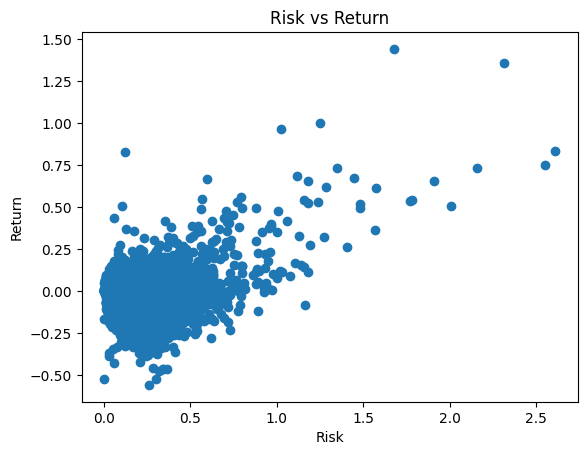

In [4]:
plt.figure()
plt.scatter(summary['risk'], summary['mean_return'])
plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("Risk vs Return")
plt.show()

The scatter plot shows that the relationship between risk and return is not very clear.

# 6. Risk Group Comparison

risk_group
Low      -0.034283
Medium   -0.051032
High     -0.035965
Name: mean_return, dtype: Float64


/var/folders/7p/049rgxzd6mjczbc7749cp3m40000gn/T/ipykernel_41438/1806758861.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_result = summary.groupby('risk_group')['mean_return'].mean()


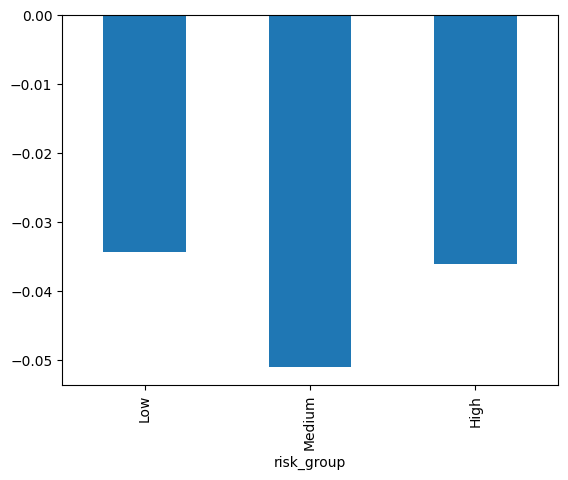

In [5]:
summary['risk_group'] = pd.qcut(summary['risk'], 3, labels=['Low', 'Medium', 'High'])

group_result = summary.groupby('risk_group')['mean_return'].mean()
print(group_result)

group_result.plot(kind='bar')
plt.show()

# 7. Correlation Analysis

In [6]:
corr = summary['risk'].corr(summary['mean_return'])

print("Correlation between risk and return:", corr)

Correlation between risk and return: 0.3349193846092486


This confirms that the relationship between risk and return is weak.

# 8. Top vs Bottom Stocks

In [7]:
top_stocks = summary.sort_values('mean_return', ascending=False).head(5)
bottom_stocks = summary.sort_values('mean_return').head(5)

print("Top stocks:")
print(top_stocks)

print("Bottom stocks:")
print(bottom_stocks)

Top stocks:
        mean_return      risk risk_group
permno                                  
16820       1.44102  1.677633       High
17360      1.357772  2.315853       High
57913      1.001121  1.248958       High
17354      0.966222  1.024862       High
91128      0.831668  2.609221       High
Bottom stocks:
        mean_return      risk risk_group
permno                                  
93350     -0.556611  0.259643       High
11182     -0.524045  0.002257        Low
92820     -0.523606  0.300907       High
93422     -0.476074  0.317297       High
92842     -0.464119  0.338508       High


Some low-risk stocks still perform well, showing that risk alone is not enough.

# 9. Risk Classification Function

In [8]:
def classify_risk(risk):
    if risk < summary['risk'].quantile(0.33):
        return "Low"
    elif risk < summary['risk'].quantile(0.66):
        return "Medium"
    else:
        return "High"

summary['risk_level'] = summary['risk'].apply(classify_risk)

This function classifies stocks into different risk categories.

# 10. Basic Python Structures

In [11]:
returns_list = summary['mean_return'].tolist()

risk_dict = dict(zip(summary['permno'], summary['risk']))

# ✅ tuple（补齐课程要求）
sample_tuple = (returns_list[0], returns_list[1])
print("Sample tuple:", sample_tuple)

# loop + if
count = 0
for r in returns_list:
    if r > 0:
        count += 1

print("Positive-return stocks:", count)

Sample tuple: (-0.0811205, 0.30724850000000004)
Positive-return stocks: 1609


# 11. Portfolio Simulation
This section simulates random portfolios to test whether diversification can improve return stability.

In [15]:
sample = summary['permno'].sample(20)

portfolio_returns = []

for i in range(50):
    weights = np.random.random(len(sample))
    weights /= weights.sum()

    temp = df[df['permno'].isin(sample)]
    pivot = temp.pivot(index='date', columns='permno', values='ret').fillna(0)

    port_ret = (pivot * weights).sum(axis=1).mean()
    portfolio_returns.append(port_ret)

print("Average portfolio return:", np.mean(portfolio_returns))

Average portfolio return: -0.05168552815090834


Diversification can help stabilize returns.

 # 12. Export Results

In [16]:
summary.to_excel("stock_summary.xlsx")

# 13. Target Users & Value

## Target Users and Value

This project is designed for:

### Beginner Investors
Helps them understand that higher risk does not always mean higher return.

### Retail Investors
Provides risk classification to support better stock selection.

### Students
Demonstrates how to use Python and real financial data for analysis.

---

## Practical Value

- Helps users make data-driven decisions  
- Reduces reliance on assumptions  
- Provides a simple framework for evaluating stocks  

# 14. Business Insight

## Business Insight

This project can be extended into a simple investment tool:

- Users input risk preference  
- System suggests stocks  
- Portfolio simulation provides diversification strategies  

This shows how data analysis can be applied in real-world finance.

# 15. Insights

- High-risk stocks do not always generate higher returns.
- There is weak correlation between risk and return.
- Market returns fluctuate significantly over time.

## 16. Final Conclusion

Based on the analysis:

- There is no strong evidence that higher risk leads to higher return  
- The correlation between risk and return is weak  
- Some low-risk stocks can still achieve good performance  

This suggests that investors should not rely on risk alone when making decisions, and diversification is important.